### Week-4 Task
#### 1.Identify country-level content contributions. 
#### 2.Create derived features such as “Content Length Category” and “Original vs. Licensed” (if derivable from dataset).

#### 1.Identify country-level content contributions.
##### Country-level content contribution means analyzing which countries produce the most movies and TV shows available on Netflix. This helps us understand how different countries contribute to Netflix’s global content library and which regions produce the most content

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object    

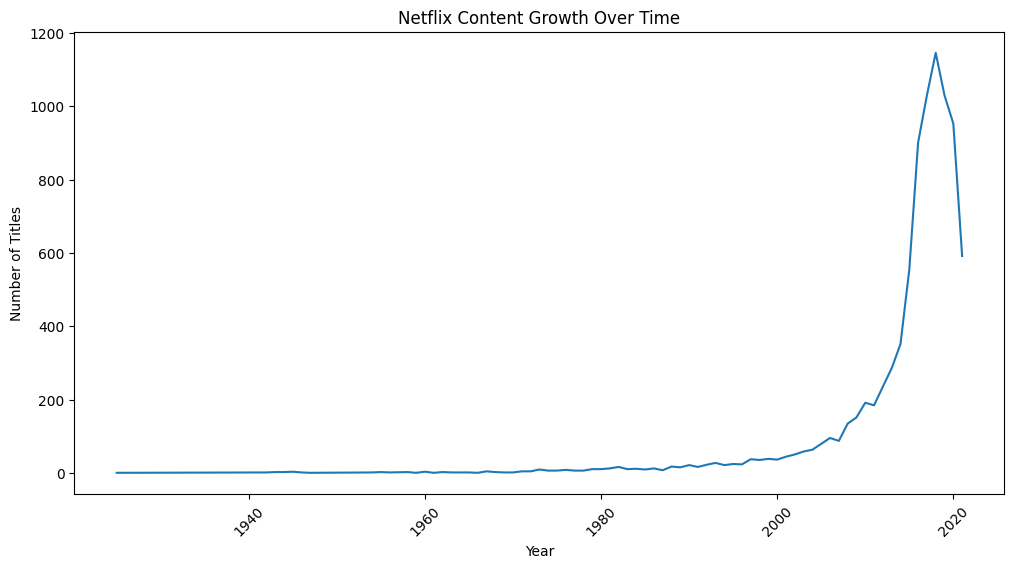

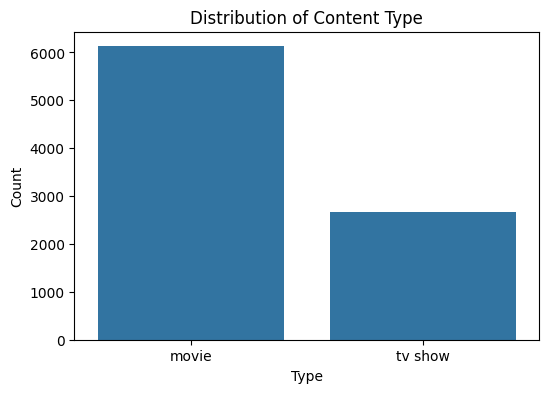

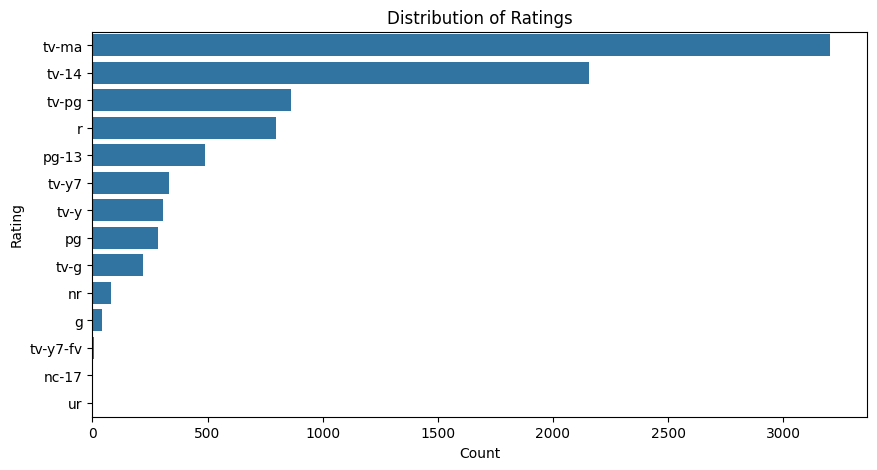

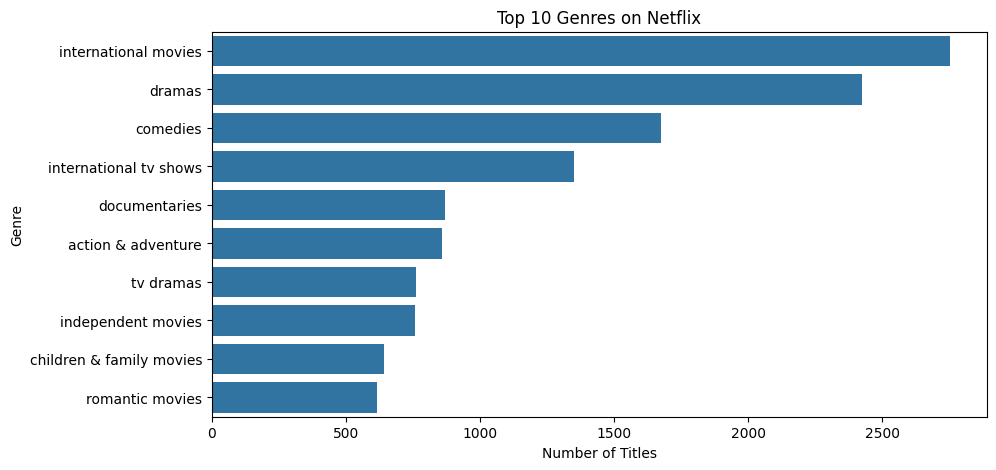

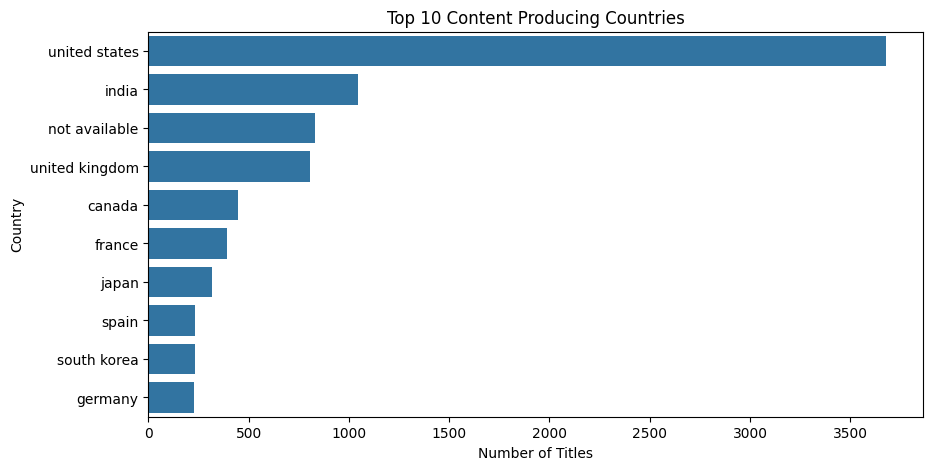

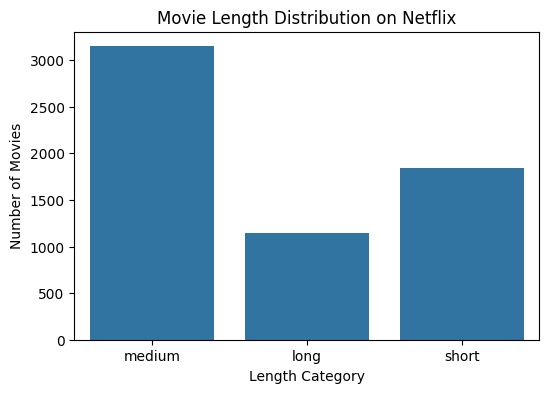

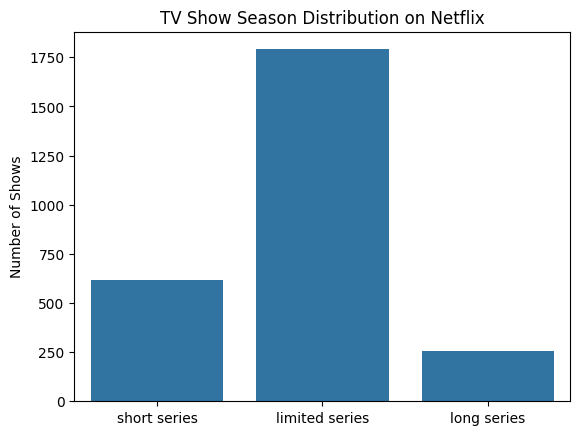

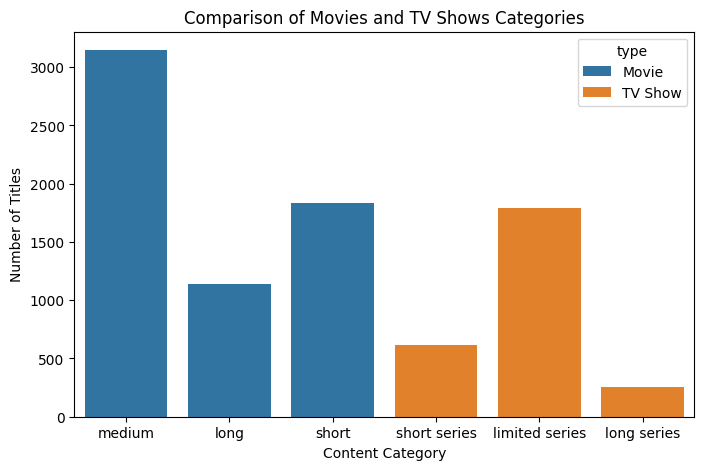

In [2]:
%run week_3.ipynb

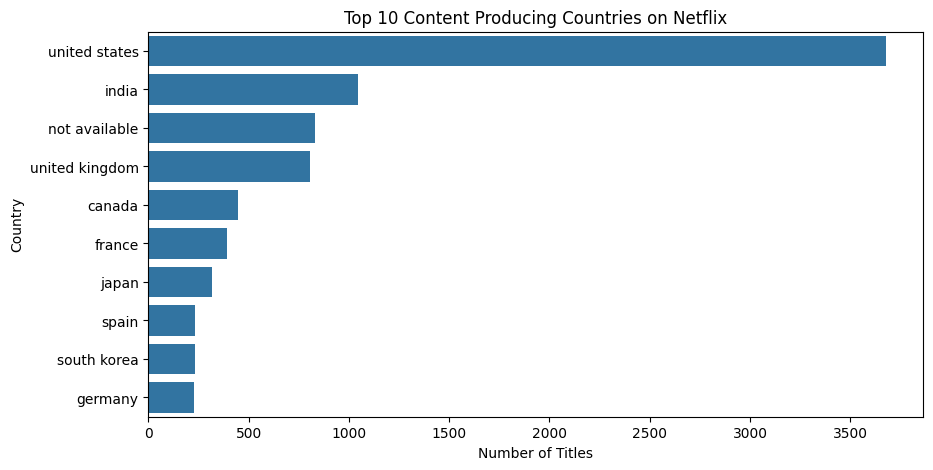

In [3]:
countries = df['country'].copy().str.split(',').explode().str.strip()

top_countries = countries.value_counts().head(10)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### 2.Create derived features such as “Content Length Category” and “Original vs. Licensed” (if derivable from dataset).

#### Content Length Category

#### The duration column contains values in minutes for movies and seasons for TV shows. Therefore, the duration was separated into two columns: duration_minutes and duration_seasons. Based on movie duration, a new feature called content_length_category was created to classify movies into short, medium, and long categories, while TV shows were labeled separately.

In [4]:
content_length_category = df['duration'].apply(
    lambda x: "short movie" if "min" in str(x) and int(x.split()[0]) < 90
    else "medium movie" if "min" in str(x) and int(x.split()[0]) <= 120
    else "long movie" if "min" in str(x)
    else "limited series" if "Season" in str(x) and int(x.split()[0]) == 1
    else "short series" if "Season" in str(x) and int(x.split()[0]) <= 3
    else "long series"
)

content_length_category.value_counts()

duration
medium movie      3147
short movie       1837
limited series    1791
long movie        1142
short series       619
long series        254
Name: count, dtype: int64

### Original vs Licensed Content

### Using date_added vs release_year 

### If a title is added to Netflix in the same year it was released, it is likely a Netflix Original.

### If the release year is earlier, it is probably licensed content.

In [5]:
df['date_added'] = pd.to_datetime(df['date_added'])

content_origin = df.apply(
    lambda x: "original" if x['release_year'] == x['date_added'].year else "licensed",
    axis=1
)

content_origin.value_counts()

licensed    5551
original    3239
Name: count, dtype: int64

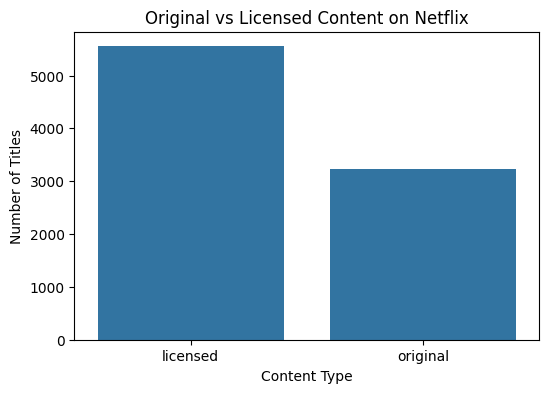

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x=content_origin)

plt.title("Original vs Licensed Content on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()